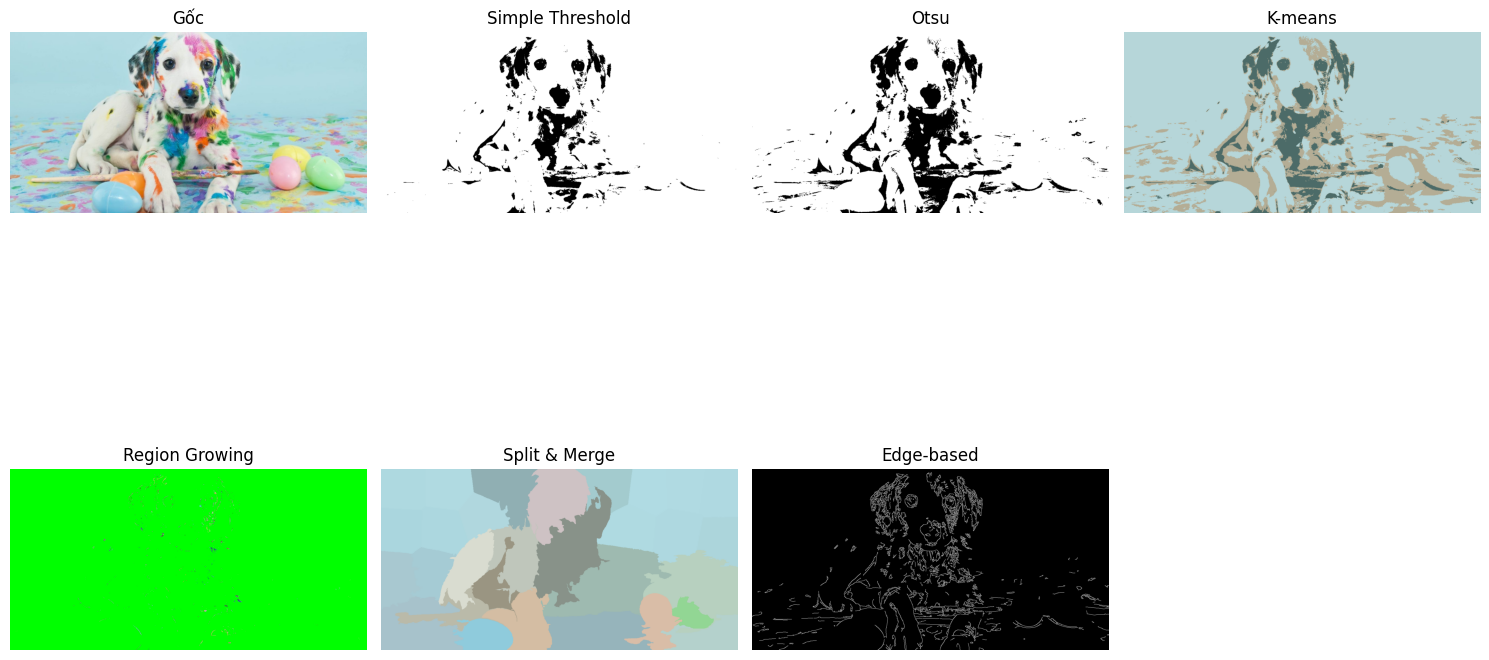

True

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as Duc
from sklearn.cluster import KMeans
from skimage import segmentation, color

img = cv2.imread('dog.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, thresh1 = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

ret_otsu, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
k = 3
_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
segmented_kmeans = centers[labels.flatten()].reshape(img_rgb.shape)

seed_point = (img.shape[1]//2, img.shape[0]//2)
region_growing = img.copy()
cv2.floodFill(region_growing, None, seed_point, (0, 255, 0), (20, 20, 20), (20, 20, 20))

labels_slic = segmentation.slic(img_rgb, n_segments=50, compactness=10, sigma=1)
split_merge_res = color.label2rgb(labels_slic, img_rgb, kind='avg')

edges = cv2.Canny(gray, 100, 200)

titles = ['Gốc', 'Simple Threshold', 'Otsu', 'K-means', 'Region Growing', 'Split & Merge', 'Edge-based']
images = [img_rgb, thresh1, thresh_otsu, segmented_kmeans, region_growing, split_merge_res, edges]

Duc.figure(figsize=(15, 10))
for i in range(7):
    Duc.subplot(2, 4, i+1)
    Duc.imshow(images[i], cmap='gray' if i in [1, 2, 6] else None)
    Duc.title(titles[i])
    Duc.axis('off')
    
Duc.tight_layout()
Duc.show()

cv2.imwrite('1_threshold.jpg', thresh1)
cv2.imwrite('2_otsu.jpg', thresh_otsu)
cv2.imwrite('3_kmeans.jpg', cv2.cvtColor(segmented_kmeans, cv2.COLOR_RGB2BGR))
cv2.imwrite('6_edge.jpg', edges)